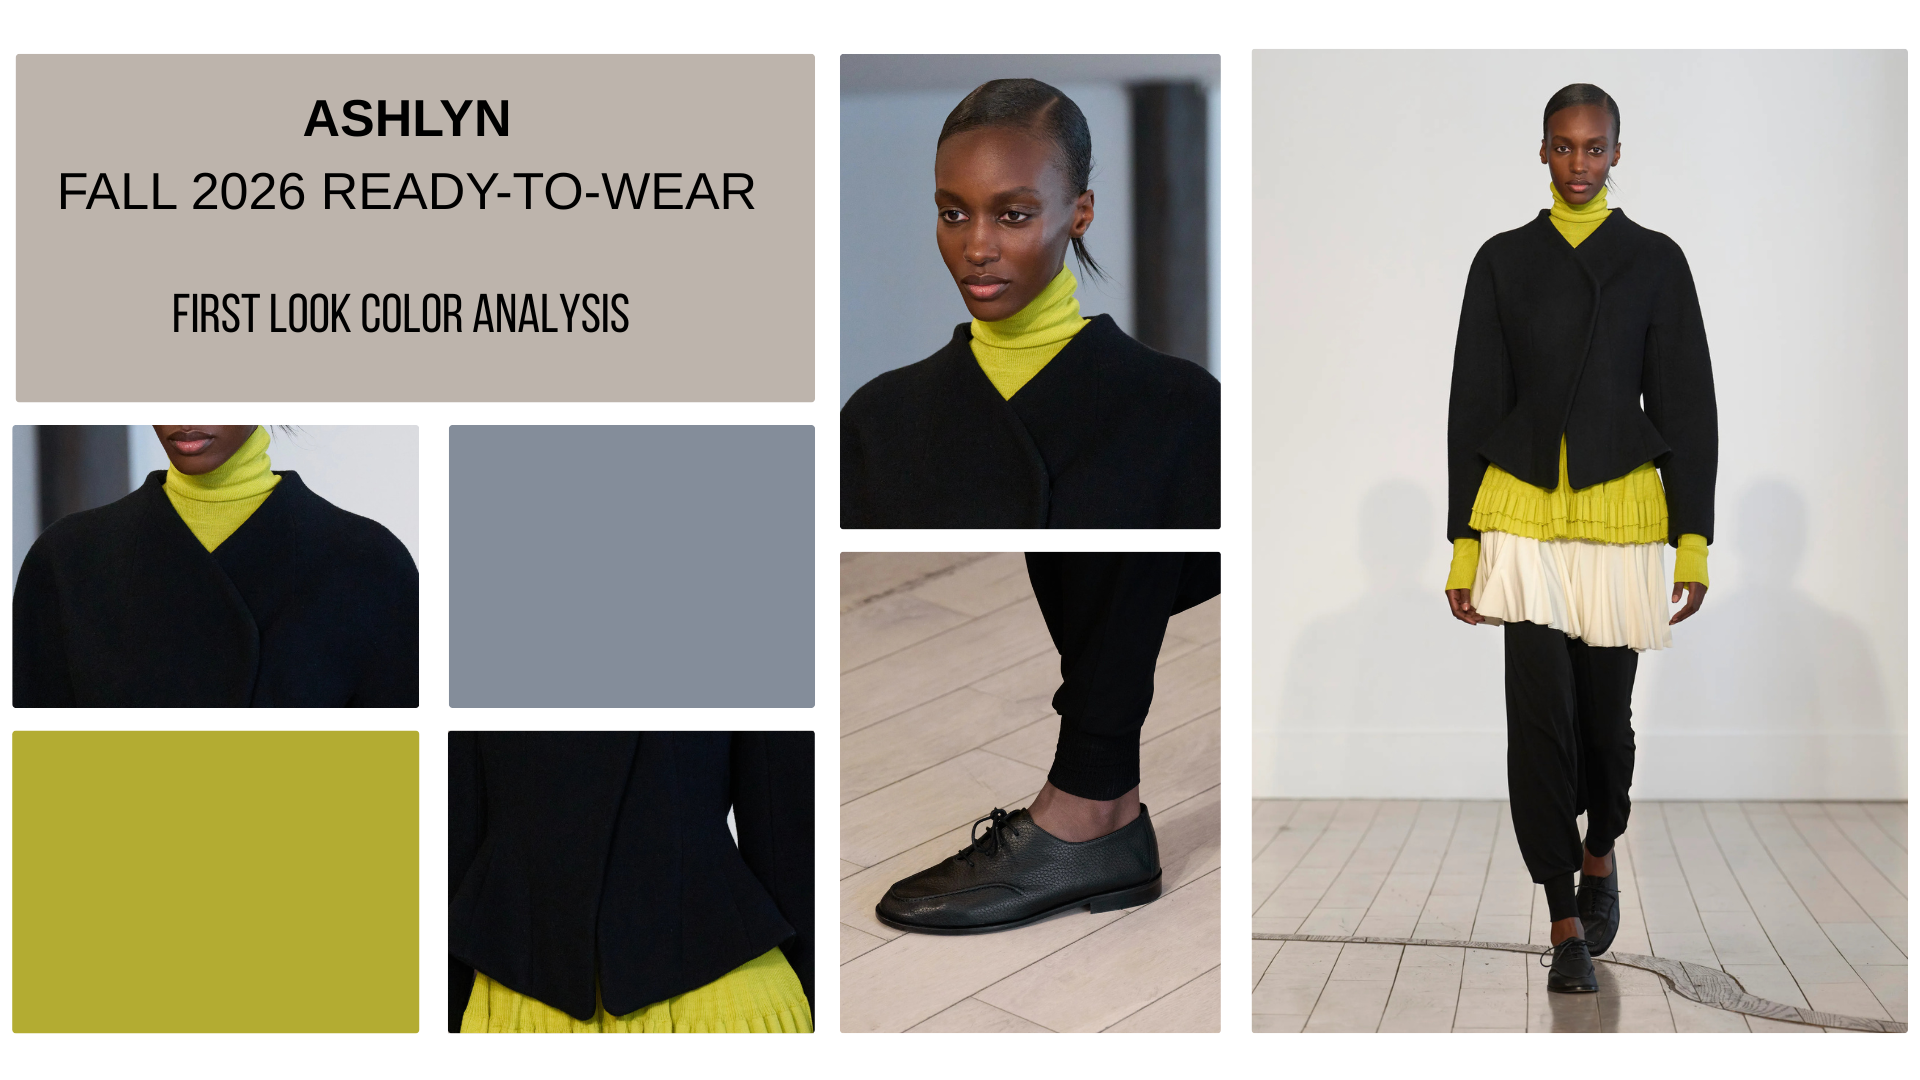


Following the methodology from:https://medium.com/@anastazijavucenovic/computer-vision-x-vogue-runway-b5c0ceca98e3

In [151]:
# Import necessities
import torch
import torchvision
from PIL import Image
from torchvision import transforms
from sklearn.cluster import KMeans
from collections import Counter
import matplotlib.pyplot as plt
from google.colab import files
import numpy as np
import os
import cv2

In [152]:
# Uploading Ahslyn file
uploaded = files.upload()
filename = list(uploaded.keys())[0]
print(f"Uploaded: {filename}")

Saving ashlyn.webp to ashlyn.webp
Uploaded: ashlyn.webp


https://developers.arcgis.com/python/latest/guide/how-deeplabv3-works/

I was experimenting with DeepLabV3 as I was trying to find the best way to use it. DeepLabV3 has three different model structures that provide the backbone: ResNet50, ResNet101, and MobileNet_v3_large. Each structure balances accuracy and speed: ResNet50 is the middle ground, ResNet101 is the most accurate but slowest, and MobileNet is the fastest but least accurate.

I ended up testing all three and found that MobileNet_v3_large performed the worst while ResNet101 performed the best. Even with ResNet101 performing the best, some of the garment was not showing up completely, which is why I had to experiment with the size. Using (513, 513) worked because it provided a larger input resolution, which helped capture more detail and allowed the model to detect the garment more completely. The bigger size gives the model more pixels to work with.

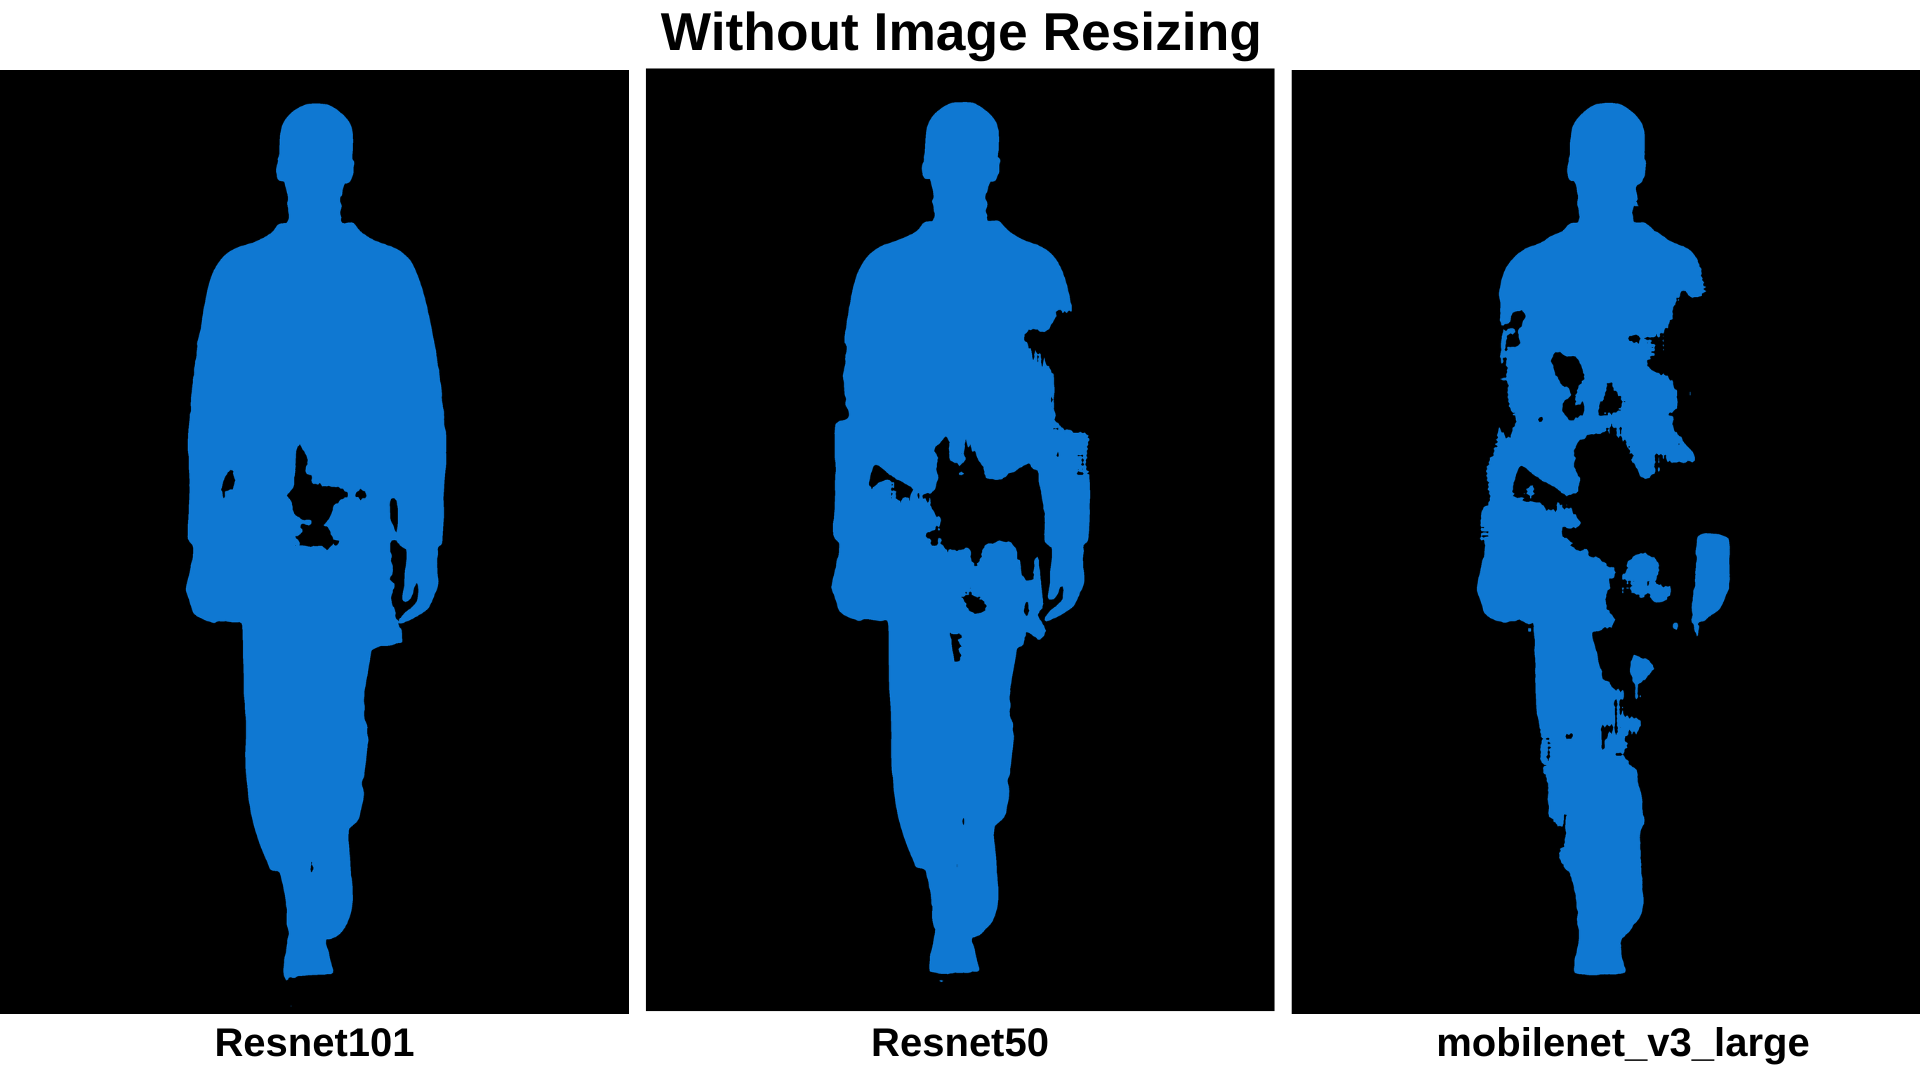

Using cache found in /root/.cache/torch/hub/pytorch_vision_v0.10.0
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=DeepLabV3_ResNet101_Weights.COCO_WITH_VOC_LABELS_V1`. You can also use `weights=DeepLabV3_ResNet101_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


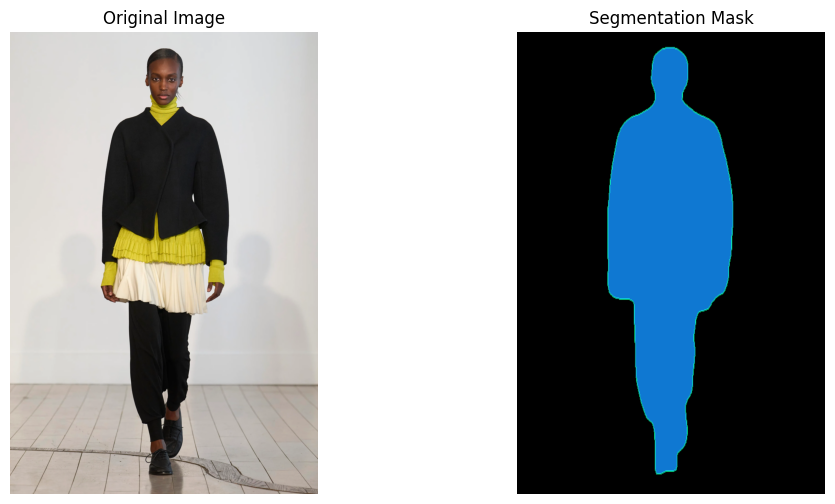

In [153]:
# Load model (DeepLabV3 with ResNet101 backbone)
# Reference material: https://pytorch.org/hub/pytorch_vision_deeplabv3_resnet101/
model = torch.hub.load(
    'pytorch/vision:v0.10.0',
    'deeplabv3_resnet101',
    pretrained=True
)
model.eval()

# Load and process the jpeg and look into converting it to color hue
input_image = Image.open(filename)
input_image = input_image.convert("RGB")

preprocess = transforms.Compose([
    # a key to get the whole image to be taken in was to rearrange the image to more closeling fit the default output size
    # alllows for the shrinkage of the image to be less harsh, larger size = more pixels can be identified
    transforms.Resize((513, 513)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    ),
])

input_tensor = preprocess(input_image)
input_batch = input_tensor.unsqueeze(0)

# Run inference to get the image
with torch.no_grad():
    output = model(input_batch)['out'][0]
    output_predictions = output.argmax(0)

# Create color to isolate the runway model (colors are referenced)
palette = torch.tensor([2**25 - 1, 2**15 - 1, 2**21 - 1])
colors = torch.arange(21)[:, None] * palette
colors = (colors % 255).numpy().astype("uint8")

# Create segmentation mask to then get the image
segmentation_mask = Image.fromarray(
    output_predictions.byte().cpu().numpy()
).resize(input_image.size)

segmentation_mask.putpalette(colors)

# Display results
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.imshow(input_image)
plt.title('Original Image')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(segmentation_mask)
plt.title('Segmentation Mask')
plt.axis('off')

plt.show()

In [154]:
# Convert to numpy arrays for OpenCV
# Reference material: https://www.geeksforgeeks.org/python/opencv-python-tutorial/
image_cv = np.array(input_image)
image_cv = cv2.cvtColor(image_cv, cv2.COLOR_RGB2BGR)  # OpenCV uses BGR

# Create person mask (class 15 is person in Pascal VOC)
person_mask_small = (output_predictions.cpu().numpy() == 15).astype(np.uint8) * 255

#
person_mask = cv2.resize(
    person_mask_small,
    (image_cv.shape[1], image_cv.shape[0]),  # (width, height)
    interpolation=cv2.INTER_LINEAR # To balance quality and speed while resizing
)

print(f"Resized mask shape: {person_mask.shape}, Image shape: {image_cv.shape[:2]}")

# First thing I did what remove head using face detection
face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')

# Convert to grayscale for face detection (detectMultiScale() expects a grayscale image)
# Followed: https://www.geeksforgeeks.org/python/face-extraction-in-opencv/
gray = cv2.cvtColor(image_cv, cv2.COLOR_BGR2GRAY)

faces = face_cascade.detectMultiScale(gray, 1.1, 4)

# Initialize head_excluded_mask before using it
head_excluded_mask = person_mask.copy()

# Detect the face, since I know there's just one, no need to complicate
#Enlarge the face box (experimented and ended up with 50%) to include the slick back bun

(x, y, w, h) = faces[0]
enlarge_factor = 0.5

#Calculate new coordinates with bounds checking
new_x = max(0, int(x - w * 0.2))  # widen a bit left
new_y = max(0, int(y - h * enlarge_factor))  # Extend upward for bun

# Calculate new width and height with proper bounds
new_w = min(person_mask.shape[1] - new_x, int(w * 1.4))  # wider
new_h = min(person_mask.shape[0] - new_y, int(h * 1.5))  # Taller

# Ensure width and height are positive
new_w = max(1, new_w)
new_h = max(1, new_h)

# Calculate rectangle end points
x2 = new_x + new_w
y2 = new_y + new_h

# Ensure within bounds
x2 = min(x2, person_mask.shape[1])
y2 = min(y2, person_mask.shape[0])

# Fill rectangle with 0 to remove head
cv2.rectangle(head_excluded_mask, (new_x, new_y), (x2, y2), 0, -1)

# Verify mask dimensions match image dimensions
print(f"Image shape: {image_cv.shape}, Mask shape: {head_excluded_mask.shape}")
print(f"Mask type: {head_excluded_mask.dtype}, Unique values: {np.unique(head_excluded_mask)}")

# Apply head-excluded mask
body_only = cv2.bitwise_and(image_cv, image_cv, mask=head_excluded_mask)

# Removing skin using HSV color space for easier idenitifcation
# Reference: https://www.geeksforgeeks.org/computer-vision/choosing-the-correct-upper-and-lower-hsv-boundaries-for-color-detection-with-cv-inrange-opencv/
hsv = cv2.cvtColor(body_only, cv2.COLOR_BGR2HSV)

# Define skin color range for African American skin range
lower_skin = np.array([0, 30, 30])  # Lower saturation and value for darker skin
upper_skin = np.array([30, 255, 180])  # Higher hue range, cap value to avoid dark clothing
# Note: Was attempting to remove the nail color as well, but ended up getting too complicated with the other color range

# Create skin mask
skin_mask = cv2.inRange(hsv, lower_skin, upper_skin)

# Apply Gaussian blur to skin mask to remove noise
skin_mask = cv2.GaussianBlur(skin_mask, (5, 5), 0)

# Invert skin mask (we want non-skin pixels)
non_skin_mask = cv2.bitwise_not(skin_mask)

# Combine with head-excluded mask
final_mask = cv2.bitwise_and(head_excluded_mask, non_skin_mask)

# Apply final mask to get clothing only
clothing_only = cv2.bitwise_and(image_cv, image_cv, mask=final_mask)


Resized mask shape: (3360, 2240), Image shape: (3360, 2240)
Image shape: (3360, 2240, 3), Mask shape: (3360, 2240)
Mask type: uint8, Unique values: [  0   1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17
  18  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35
  36  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53
  54  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71
  72  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88  89
  90  91  92  93  94  95  96  97  98  99 100 101 102 103 104 105 106 107
 108 109 110 111 112 113 114 115 116 117 118 119 120 121 122 123 124 125
 126 127 128 129 130 131 132 133 134 135 136 137 138 139 140 141 142 143
 144 145 146 147 148 149 150 151 152 153 154 155 156 157 158 159 160 161
 162 163 164 165 166 167 168 169 170 171 172 173 174 175 176 177 178 179
 180 181 182 183 184 185 186 187 188 189 190 191 192 193 194 195 196 197
 198 199 200 201 202 203 204 205 206 207 208 209 

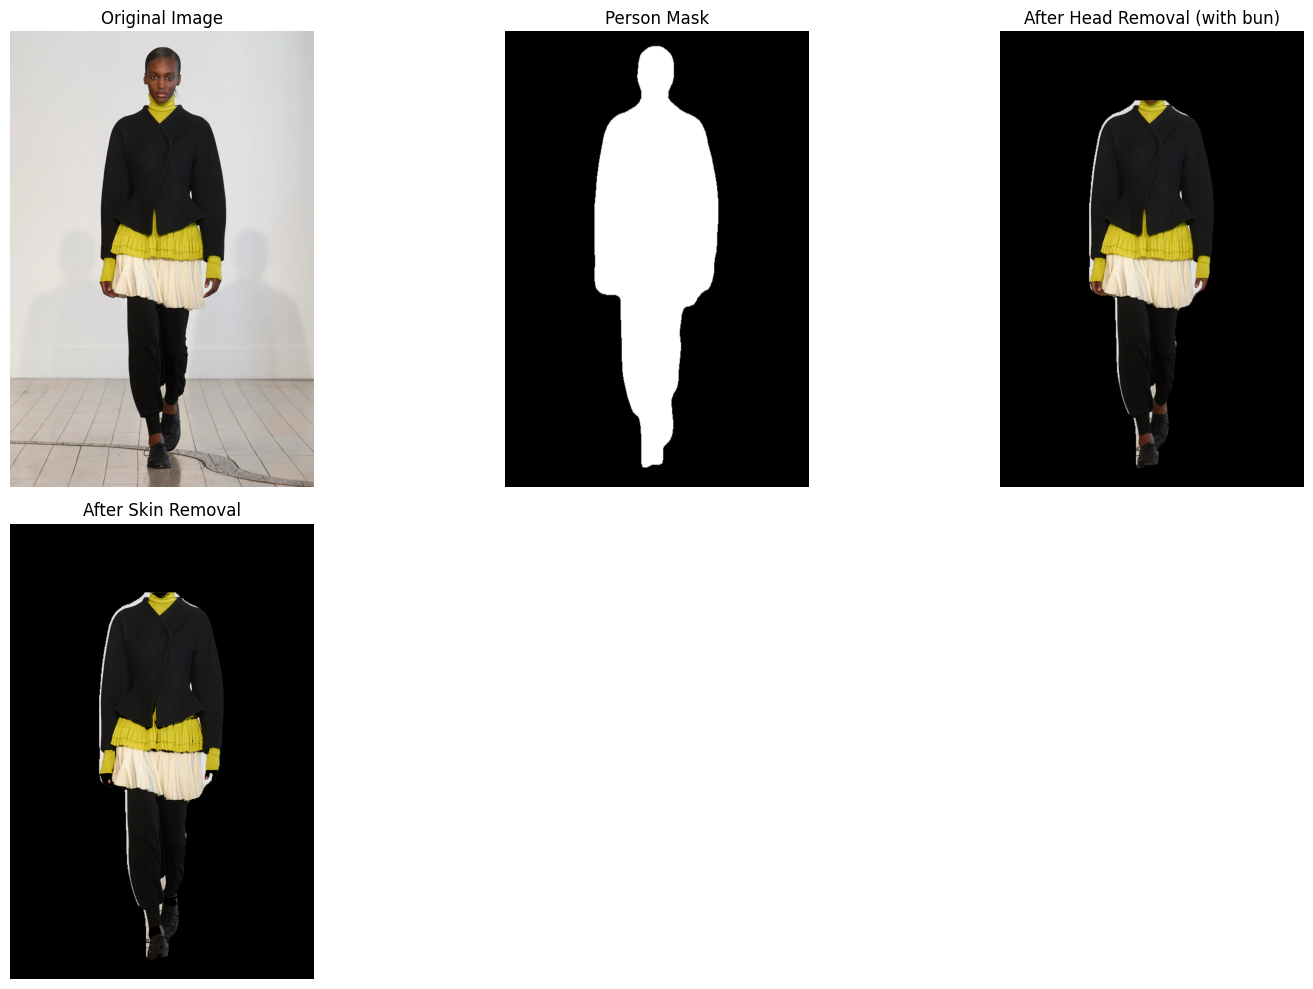

In [155]:
plt.figure(figsize=(15, 10))

plt.subplot(2, 3, 1)
plt.imshow(cv2.cvtColor(image_cv, cv2.COLOR_BGR2RGB))
plt.title('Original Image')
plt.axis('off')

plt.subplot(2, 3, 2)
plt.imshow(person_mask, cmap='gray')
plt.title('Person Mask')
plt.axis('off')

plt.subplot(2, 3, 3)
plt.imshow(cv2.cvtColor(body_only, cv2.COLOR_BGR2RGB))
plt.title('After Head Removal (with bun)')
plt.axis('off')

plt.subplot(2, 3, 4)
plt.imshow(cv2.cvtColor(clothing_only, cv2.COLOR_BGR2RGB))
plt.title('After Skin Removal')
plt.axis('off')

plt.tight_layout()
plt.show()

I tried to automatically filter out the outline pixels here, but it didn't really pick up on the slight background that the segmentation left behind. So the logic didn't catch anything, ended up removing 0 pixels.

Quick explainer: Brightness = how light/dark the color is (0 = black, 255 = white). White Distance = how far from pure white. Size = % of clothing pixels in that cluster.

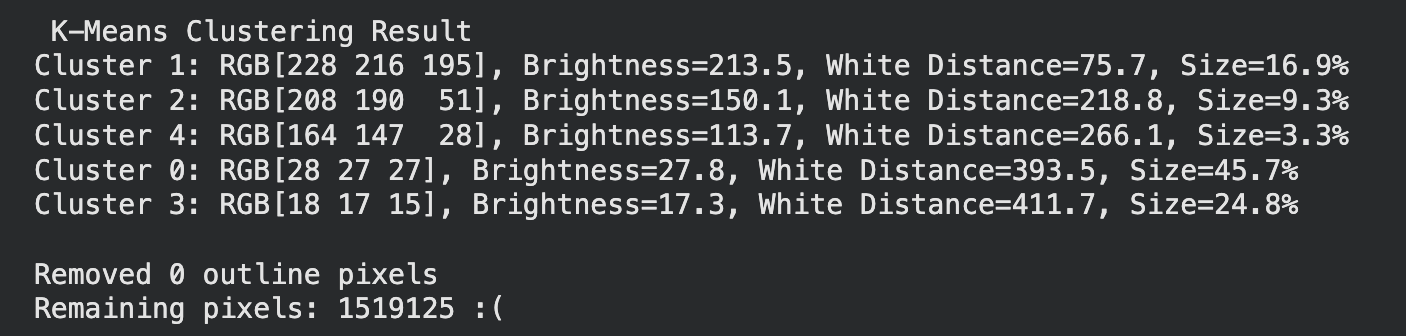

The results show two black clusters (clusters 0 and 3) that together make up about 70% of the look, a cream cluster at 16.9%, and two citron yellow clusters at 9.3% and 3.3% representing the pop of color and its shadow variations, which visually aligns with what the look was giving. My thought was that since it's so small, it wouldn't sway the final results too much.



In [156]:
# Use your 'clothing_only' image from the previous step
# Convert BGR to RGB for correct colors
clothing_rgb = cv2.cvtColor(clothing_only, cv2.COLOR_BGR2RGB)

# Get all non-black pixels (where clothing actually is)
# Black pixels are (0,0,0) from the masking
mask = np.any(clothing_rgb > [10, 10, 10], axis=-1)  # Pixels that aren't near-black
clothing_pixels = clothing_rgb[mask]

print(f"Clothing pixels identified: {len(clothing_pixels)}")

# Use KMeans to find dominant colors
k = 6  # INCREASE TO 6 CLUSTERS
kmeans = KMeans(n_clusters=k, random_state=42) # 42 is the answer for everything
kmeans.fit(clothing_pixels)

# Get colors and their frequencies
colors = kmeans.cluster_centers_
labels = kmeans.labels_

# Count pixels in each cluster
label_counts = Counter(labels)
total_pixels = sum(label_counts.values())

print("\nInitial Clusters:")
for i, color in enumerate(colors):
    percentage = (label_counts[i] / total_pixels) * 100
    print(f"Cluster {i}: RGB{color.astype(int)}, Size={percentage:.1f}%")

Clothing pixels identified: 1522491

Initial Clusters:
Cluster 0: RGB[24 23 23], Size=70.0%
Cluster 1: RGB[209 194 168], Size=4.6%
Cluster 2: RGB[180 162  23], Size=4.1%
Cluster 3: RGB[234 223 203], Size=12.5%
Cluster 4: RGB[211 194  51], Size=7.8%
Cluster 5: RGB[97 86 52], Size=1.1%


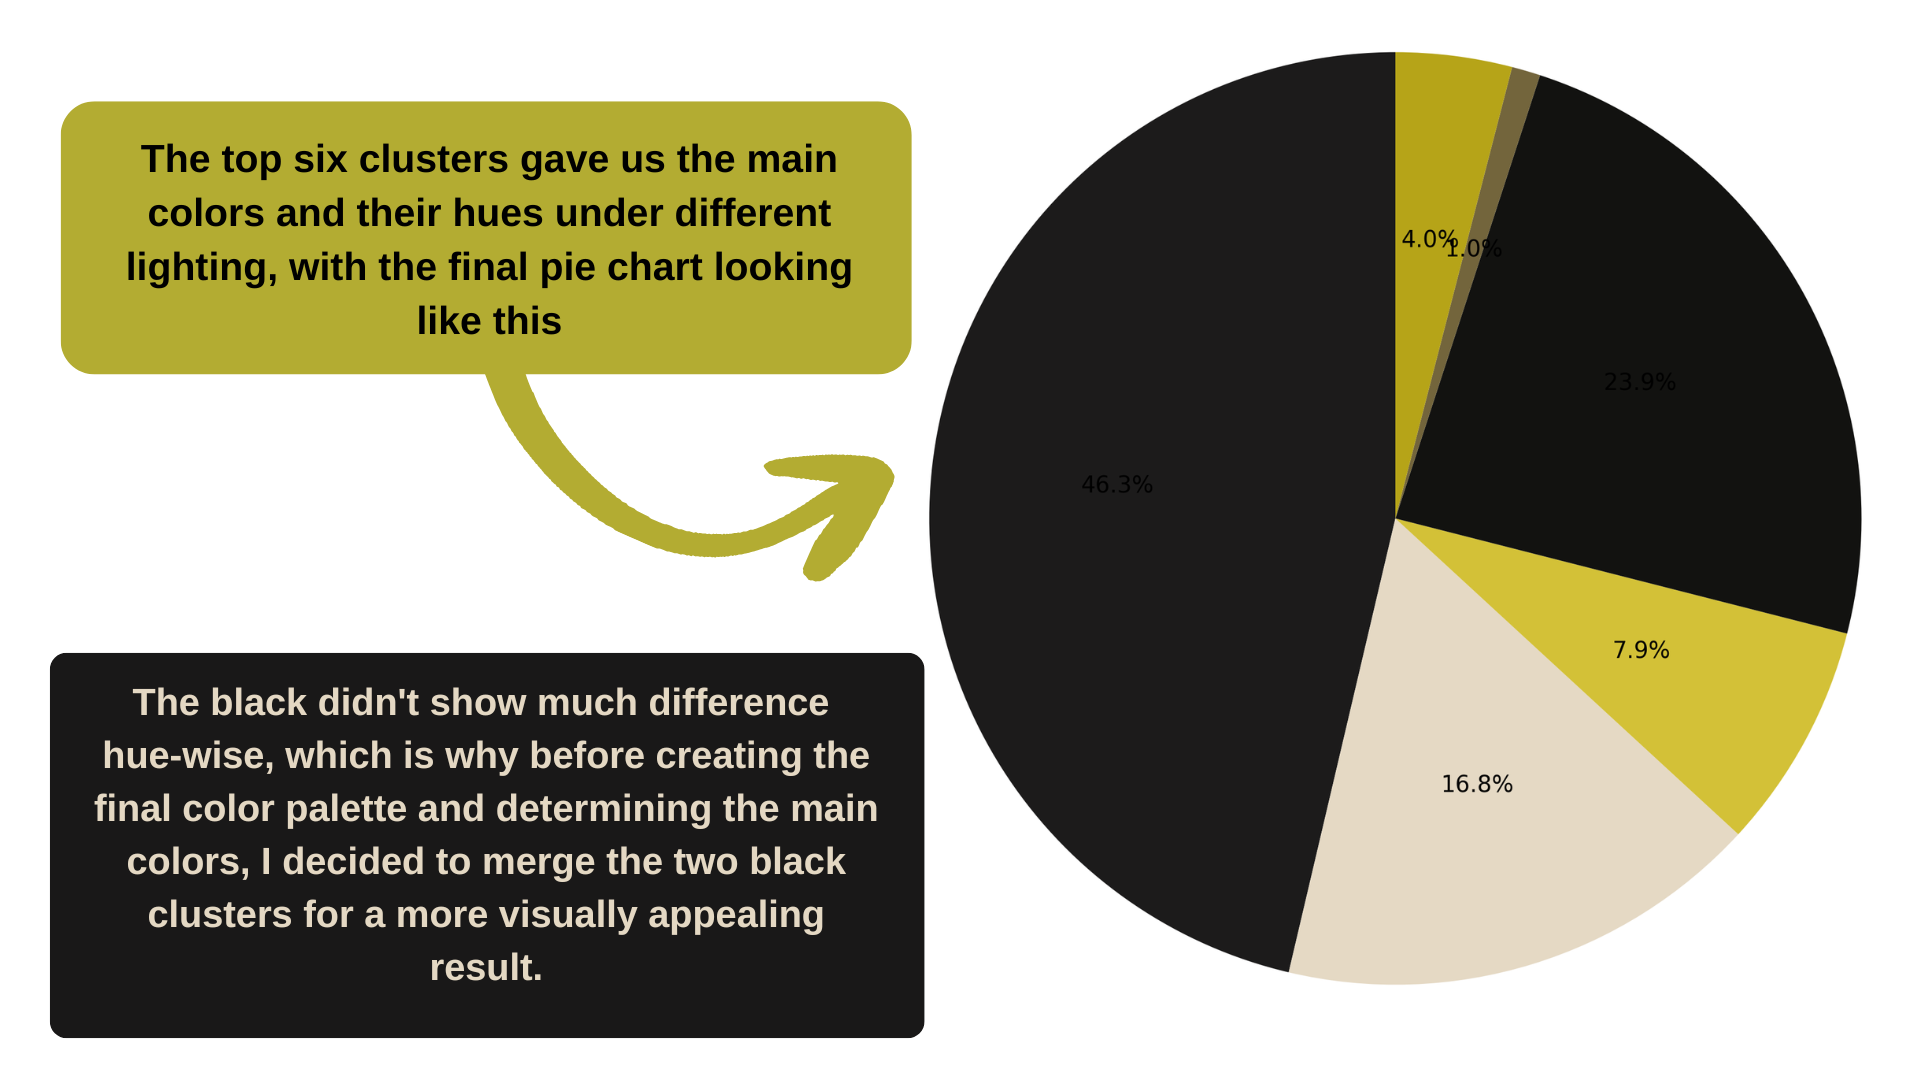

In [157]:
# Use your 'clothing_only' image from the previous step
# Convert BGR to RGB for correct colors
clothing_rgb = cv2.cvtColor(clothing_only, cv2.COLOR_BGR2RGB)

# Get all non-black pixels (where clothing actually is)
# Black pixels are (0,0,0) from the masking
mask = np.any(clothing_rgb > [10, 10, 10], axis=-1)  # Pixels that aren't near-black (no background allowed)
clothing_pixels = clothing_rgb[mask]

print(f"Clothing pixels identified: {len(clothing_pixels)}")

# Use KMeans to find dominant colors
k = 5  # Decrease the number down to 5 now (no longer need both black hues)
kmeans = KMeans(n_clusters=k, random_state=42) # 42 is the answer for everything
kmeans.fit(clothing_pixels)

# Get colors and their frequencies
colors = kmeans.cluster_centers_
labels = kmeans.labels_

# Count pixels in each cluster
label_counts = Counter(labels)
total_pixels = sum(label_counts.values())

# Find dark clusters (brightness < 50)
dark_clusters = []
light_clusters = []
for i, color in enumerate(colors):
    if np.mean(color) < 50:
        dark_clusters.append(i)
    else:
        light_clusters.append(i)

# Merge dark clusters into one black
black_percentage = sum(label_counts[i] for i in dark_clusters) / total_pixels * 100
black_color = np.zeros(3)
for i in dark_clusters:
    black_color += colors[i] * label_counts[i]
black_color = black_color / sum(label_counts[i] for i in dark_clusters)

# Create final lists
merged_colors = [black_color]
merged_percentages = [black_percentage]
merged_labels_list = ["Merged Black"]

# Add all light clusters
for i in light_clusters:
    merged_colors.append(colors[i])
    merged_percentages.append(label_counts[i] / total_pixels * 100)
    merged_labels_list.append(f"Cluster {i}")

# Sort by percentage (highest first)
sorted_indices = np.argsort(merged_percentages)[::-1]

print("\nFinal five clusters (after black is merged):")
for idx in sorted_indices:
    print(f"{merged_labels_list[idx]}: RGB{merged_colors[idx].astype(int)}, {merged_percentages[idx]:.1f}%")

Clothing pixels identified: 1522491

Final five clusters (after black is merged):
Merged Black: RGB[24 24 23], 70.6%
Cluster 3: RGB[234 223 203], 12.5%
Cluster 4: RGB[209 191  49], 9.0%
Cluster 1: RGB[209 194 168], 4.6%
Cluster 2: RGB[165 147  25], 3.3%


In [161]:
#Find dark clusters (brightness < 50)
dark_clusters = []
light_clusters = []
for i, color in enumerate(colors):
    if np.mean(color) < 50:
        dark_clusters.append(i)
    else:
        light_clusters.append(i)

# Create merged results (black plus all light clusters)
merged_colors = []
merged_percentages = []
merged_labels_list = []  # For the final display

if len(dark_clusters) > 0:
    # Merge all dark clusters into one
    black_percentage = sum(label_counts[i] for i in dark_clusters) / total_pixels * 100
    black_color = np.zeros(3)
    for i in dark_clusters:
        black_color += colors[i] * label_counts[i]
    black_color = black_color / sum(label_counts[i] for i in dark_clusters)

    merged_colors.append(black_color)
    merged_percentages.append(black_percentage)
    merged_labels_list.append("Merged Black")

# Add all light clusters
for i in light_clusters:
    merged_colors.append(colors[i])
    merged_percentages.append(label_counts[i] / total_pixels * 100)
    merged_labels_list.append(f"Cluster {i}")

# Sort by percentage (highest first)
sorted_indices = np.argsort(merged_percentages)[::-1]

print("\n Final Colors of Ashlyn's First Look:")
for idx in sorted_indices:
    print(f"{merged_labels_list[idx]}: RGB{merged_colors[idx].astype(int)}, {merged_percentages[idx]:.1f}%")



 Final Colors of Ashlyn's First Look:
Merged Black: RGB[24 24 23], 70.6%
Cluster 3: RGB[234 223 203], 12.5%
Cluster 4: RGB[209 191  49], 9.0%
Cluster 1: RGB[209 194 168], 4.6%
Cluster 2: RGB[165 147  25], 3.3%


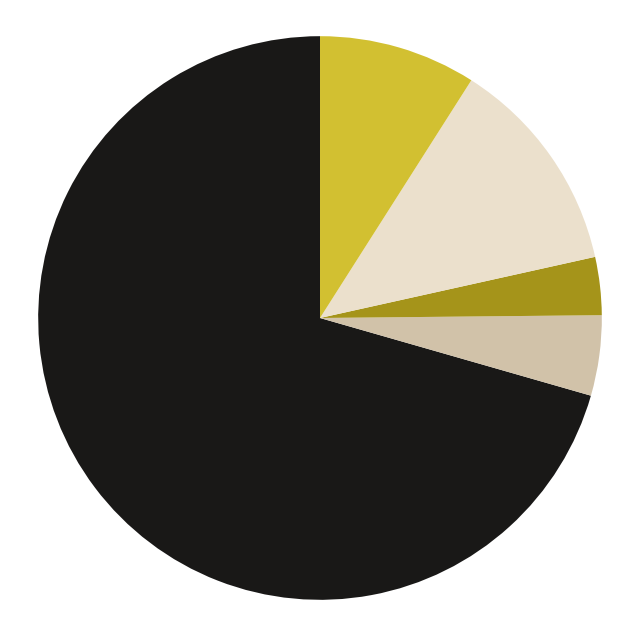

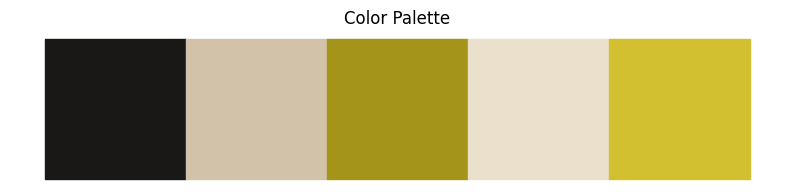

In [162]:
# After merging the clustee, now I will use merged_colors and merged_percentages for overall hue pie chart
plt.figure(figsize=(8, 8))

# Convert merged colors from 0-255 to 0-1 for matplotlib
colors_for_pie = [color/255.0 for color in merged_colors]
percentages_for_pie = merged_percentages


# Create pie chart
plt.pie(percentages_for_pie,
        colors=colors_for_pie,
        startangle=90)
plt.axis('equal')
plt.show()

# Simple color palette to show the 5 colors
plt.figure(figsize=(10, 2))
for i, color in enumerate(merged_colors):
    plt.fill_between([i, i+1], 0, 1, color=color/255.0)
plt.axis('off')
plt.title('Color Palette')
plt.show()

1. RGB[24 24 23], 70.8%
2. RGB[228 216 195], 16.9%
3. RGB[198 181  45], 12.3%


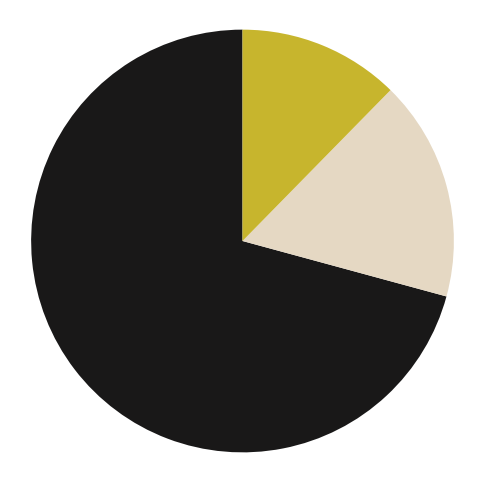

In [163]:
# Get top 3 by percentage
top_3_colors = sig_colors[:3]
top_3_percentages = sig_percentages[:3]
for i in range(min(3, len(sig_colors))):
    rgb = (np.array(sig_colors[i]) * 255).astype(int)
    print(f"{i+1}. RGB{rgb}, {sig_percentages[i]:.1f}%")

# Sort them into pie chart
plt.figure(figsize=(6, 6))
plt.pie(top_3_percentages,
        colors=top_3_colors,
        startangle=90)
plt.axis("equal")
plt.show()

Yay! We got out top 3 colors!

- Black: 70.8%
- Cream: 16.9%
- Citron Yellow: 12.3%